# 🖼️ Image Classifier — Synthetic Shapes
## Exploratory Data Analysis (EDA)

> Dataset berisi gambar grayscale 16×16 piksel dari 3 kelas geometri: **circle**, **square**, **triangle**.
> Dataset tetap dari file `.npz` agar hasilnya **identik** di VS Code maupun Google Colab.

In [2]:
"""SETUP — Wajib dijalankan sekali."""
import os
import sys

# Deteksi lingkungan Colab
IN_COLAB = "google.colab" in sys.modules

print(f"In Google Colab: {IN_COLAB}")
print(f"Working Dir : {os.getcwd()}")

# --- Klona repo bila diperlukan (agar impor internal berfungsi) ---
PROJECT_DIR = "collab-workspace"
if IN_COLAB:
    if PROJECT_DIR not in os.listdir():
        print("\n>>> Cloning collab-workspace...")
        os.system(
            "git clone "
            "https://github.com/febriyansyahresearch-lab/"
            f"{PROJECT_DIR}.git"
        )
    os.chdir(PROJECT_DIR)
else:
    # Fallback: naik hingga menemukan folder collab-workspace
    while True:
        cur = os.path.basename(os.getcwd())
        if cur == PROJECT_DIR or ".git" in os.listdir():
            break
        os.chdir("..")

sys.path.insert(0, os.getcwd())

print(f"\nFinal Working Dir : {os.getcwd()}")
assert os.path.exists("projects"), (
    "'projects/' tidak ditemukan. Pastikan anda berada di root collab-workspace."
)
print("[OK] Root collab-workspace terdeteksi.")

# --- Instal dependensi bila kurang ---
try:
    import sklearn  # noqa: F401
except ModuleNotFoundError:
    print("\n>>> Installing missing deps...")
    os.system("pip install -q -r requirements.txt")

print("\n[DONE] Setup selesai.")

In Google Colab: False
Working Dir : /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/collab-workspace

Final Working Dir : /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/collab-workspace
[OK] Root collab-workspace terdeteksi.

[DONE] Setup selesai.


In [3]:
"""
Import Library
===============
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Seaborn  : {sns.__version__}")

NumPy    : 2.5.3
Pandas   : 3.0.5
Seaborn  : 0.13.2


## 📂 Load Dataset

Dataset dimuat dari file tetap `data/image_shapes_fixed.npz` agar hasilnya identik di semua environment.

In [7]:
"""
Load Dataset dari file .npz tetap
==================================
"""

DATA_PATH = os.path.join(os.getcwd(), "data", "image_shapes_fixed.npz")
assert os.path.isfile(DATA_PATH), f"File tidak ditemukan: {DATA_PATH}"

with np.load(DATA_PATH) as d:
    X       = d["X"]                 # (n, 256) flattened
    y       = d["y"]                 # (n,) label index
    classes = [str(c) for c in d["classes"]]  # nama kelas (plain str)

IMG_SIZE = int(np.sqrt(X.shape[1]))  # 16
n, dim   = X.shape

print(f"Dimensi X        : {X.shape}")
print(f"Dimensi y        : {y.shape}")
print(f"Ukuran gambar    : {IMG_SIZE} x {IMG_SIZE} piksel")
print(f"Jumlah kelas     : {len(classes)} → {classes}")
print(f"Tipe data        : {X.dtype}")

Dimensi X        : (600, 256)
Dimensi y        : (600,)
Ukuran gambar    : 16 x 16 piksel
Jumlah kelas     : 3 → ['circle', 'square', 'triangle']
Tipe data        : float64


## 📊 Distribusi Kelas

Apakah dataset seimbang antar kelas?

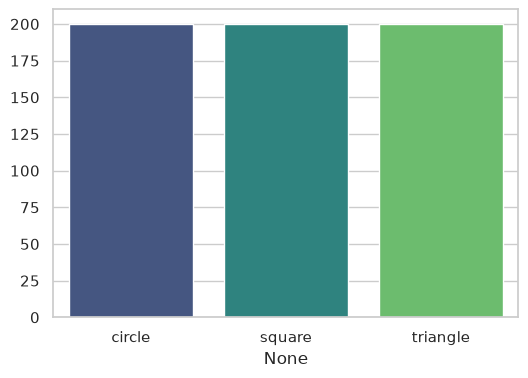

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = sns.barplot(x=counts.index, y=counts.values,
                   hue=counts.index, palette="viridis", legend=False, ax=ax)

## 🖼️ Contoh Gambar per Kelas

Visualisasi sampel acak dari setiap kelas untuk memastikan bentuk geometri terlihat jelas.

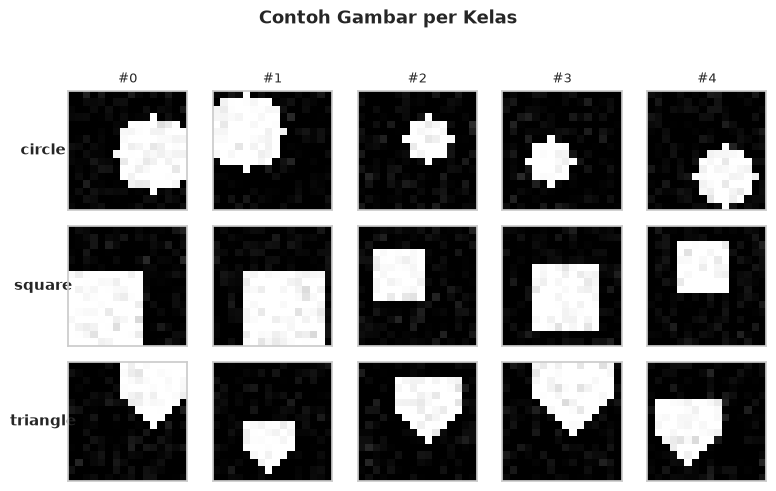

In [10]:
"""
Contoh Gambar per Kelas
========================
Grid 3 baris (per kelas) × 5 kolom (sampel).
"""

SAMPLES_PER_CLASS = 5
fig, axes = plt.subplots(len(classes), SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 1.6, len(classes) * 1.6))

for row, cls in enumerate(classes):
    idxs = np.where(y == row)[0][:SAMPLES_PER_CLASS]
    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(X[idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold", rotation=0,
                          labelpad=18, va="center")
        if row == 0:
            ax.set_title(f"#{idx}", fontsize=9)

fig.suptitle("Contoh Gambar per Kelas", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 📈 Statistik Intensitas Piksel

Rata-rata, standar deviasi, dan persentase piksel aktif per kelas — berguna untuk memahami karakteristik visual tiap bentuk.

In [11]:
"""
Statistik Intensitas Piksel
=============================
"""

rows = []
for i, cls in enumerate(classes):
    imgs = X[y == i]
    rows.append({
        "Kelas"          : cls,
        "Jumlah"         : len(imgs),
        "Mean Intensitas": imgs.mean().round(4),
        "Std Deviasi"    : imgs.std().round(4),
        "Piksel Aktif %" : round((imgs > 0.5).mean() * 100, 2),
        "Min"            : imgs.min().round(4),
        "Max"            : imgs.max().round(4),
    })

stats_df = pd.DataFrame(rows)
display(stats_df)

# Insight singkat
print("\n💡 Insight:")
print(f"  - Bentuk dengan piksel aktif terbanyak : {stats_df.loc[stats_df['Piksel Aktif %'].idxmax(), 'Kelas']}")
print(f"  - Bentuk dengan piksel aktif tersedikit: {stats_df.loc[stats_df['Piksel Aktif %'].idxmin(), 'Kelas']}")

,Kelas,Jumlah,Mean Intensitas,Std Deviasi,Piksel Aktif %,Min,Max
0,circle,200,0.2259,0.3951,21.44,0.0,1.0
1,square,200,0.3268,0.4485,31.94,0.0,1.0
2,triangle,200,0.2532,0.4129,24.30,0.0,1.0



💡 Insight:
  - Bentuk dengan piksel aktif terbanyak : square
  - Bentuk dengan piksel aktif tersedikit: circle


## 🌡️ Distribusi Intensitas Piksel

Histogram distribusi nilai piksel untuk melihat kontras antara latar belakang (noise) dan bentuk (foreground).

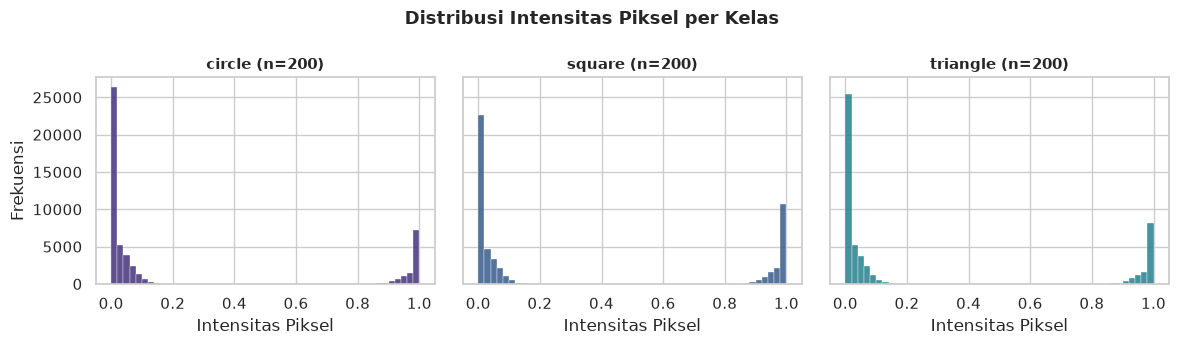

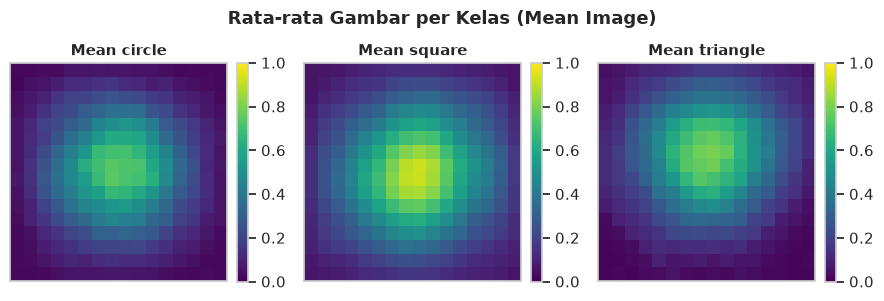

In [12]:
"""
Distribusi Intensitas Piksel
==============================
"""

fig, axes = plt.subplots(1, len(classes), figsize=(12, 3.5), sharey=True)

for i, (cls, ax) in enumerate(zip(classes, axes)):
    imgs = X[y == i]
    ax.hist(imgs.ravel(), bins=50, color=sns.color_palette("viridis")[i],
            alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{cls} (n={len(imgs)})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Intensitas Piksel")
    if i == 0:
        ax.set_ylabel("Frekuensi")

fig.suptitle("Distribusi Intensitas Piksel per Kelas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Rata-rata gambar (mean image) per kelas
fig, axes = plt.subplots(1, len(classes), figsize=(9, 3))
for i, (cls, ax) in enumerate(zip(classes, axes)):
    mean_img = X[y == i].mean(axis=0).reshape(IMG_SIZE, IMG_SIZE)
    im = ax.imshow(mean_img, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"Mean {cls}", fontsize=11, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Rata-rata Gambar per Kelas (Mean Image)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 🧠 Kesimpulan & Rekomendasi

Ringkasan temuan EDA dan langkah selanjutnya untuk pemodelan.

In [13]:
"""
Kesimpulan & Rekomendasi
==========================
"""

most_label = stats_df.loc[stats_df["Piksel Aktif %"].idxmax(), "Kelas"]
least_label = stats_df.loc[stats_df["Piksel Aktif %"].idxmin(), "Kelas"]

summary_lines = [
    f"1. **Dataset seimbang** — {len(classes)} kelas dengan {counts.min()} gambar per kelas "
    f"(rasio {balance_ratio:.2f}), tidak perlu teknik resampling.",
    f"2. **Resolusi kecil (16×16)** — hanya {dim} fitur per gambar; model sederhana "
    f"(MLP/CNN kecil) sudah cukup.",
    f"3. **Kontras jelas** — piksel bentuk ≈ 1.0 vs latar ≈ noise (std ~0.05), "
    f"sehingga klasifikasi relatif mudah.",
    f"4. **Karakteristik berbeda** — '{most_label}' punya piksel aktif terbanyak, "
    f"'{least_label}' paling sedikit → fitur pembeda yang kuat.",
    f"5. **Data tetap** — dataset dari .npz memastikan hasil reproduksibel di semua environment.",
]

rec_lines = [
    "• **Model**: mulai dengan Logistic Regression / MLP sederhana sebagai baseline.",
    "• **Evaluasi**: gunakan stratified split (train/val/test) karena kelas seimbang.",
    "• **Augmentasi**: rotasi/translasi kecil dapat diuji untuk meningkatkan generalisasi.",
    "• **Fitur**: mean image per kelas bisa dijadikan template matching sederhana.",
    "• **Reproduksibilitas**: selalu set seed & gunakan dataset tetap (.npz).",
]

print("=" * 70)
print("KESIMPULAN")
print("=" * 70)
for line in summary_lines:
    print(f"  {line}")
print()
print("=" * 70)
print("REKOMENDASI")
print("=" * 70)
for line in rec_lines:
    print(f"  {line}")

KESIMPULAN
  1. **Dataset seimbang** — 3 kelas dengan 200 gambar per kelas (rasio 1.00), tidak perlu teknik resampling.
  2. **Resolusi kecil (16×16)** — hanya 256 fitur per gambar; model sederhana (MLP/CNN kecil) sudah cukup.
  3. **Kontras jelas** — piksel bentuk ≈ 1.0 vs latar ≈ noise (std ~0.05), sehingga klasifikasi relatif mudah.
  4. **Karakteristik berbeda** — 'square' punya piksel aktif terbanyak, 'circle' paling sedikit → fitur pembeda yang kuat.
  5. **Data tetap** — dataset dari .npz memastikan hasil reproduksibel di semua environment.

REKOMENDASI
  • **Model**: mulai dengan Logistic Regression / MLP sederhana sebagai baseline.
  • **Evaluasi**: gunakan stratified split (train/val/test) karena kelas seimbang.
  • **Augmentasi**: rotasi/translasi kecil dapat diuji untuk meningkatkan generalisasi.
  • **Fitur**: mean image per kelas bisa dijadikan template matching sederhana.
  • **Reproduksibilitas**: selalu set seed & gunakan dataset tetap (.npz).
